In [17]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [23]:
#Define state
class BMI(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    category:str

In [24]:
def calculate_bmi(state:BMI)->BMI:
    weight=state['weight_kg']
    height=state['height_m']
    bmi=weight/(height**2)
    state['bmi']=round(bmi,2)
    return state

In [25]:
def label_bmi(state:BMI)->BMI:
    bmi=state['bmi']
    
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [26]:
#define the the graph
graph=StateGraph(BMI)
#add nodes to the graph
graph.add_node('compute_bmi',calculate_bmi)
graph.add_node('label_bmi',label_bmi)
#add edges to the graph
graph.add_edge(START,'compute_bmi')
graph.add_edge('compute_bmi','label_bmi')
graph.add_edge('label_bmi',END)
#compile the graph
workflow=graph.compile()
#execute the graph
initial_state={'weight_kg':80,'height_m':1.73}
final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


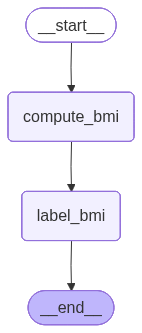

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())